# L03 · Bayes' Rule, Bayes Classifiers and DNA Motifs

*Companion notebook for Lecture 3 — Probability and Bayes Classifiers (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**
1. Compute the positive predictive value (PPV) of a diagnostic test with Bayes' rule.
2. Build the Bayes-optimal classifier for two Gaussian classes and see how priors and costs move the threshold.
3. Fit Gaussian naive Bayes and check how well calibrated its probabilities are.
4. Treat a transcription-factor motif (position weight matrix) as a generative model and score DNA with the log-likelihood ratio.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score
import course_utils as cu

rng = cu.seed_everything(0)
cu.plot_style()

## 1. Bayes' rule for a diagnostic test
$P(D\mid +) = \dfrac{P(+\mid D)P(D)}{P(+\mid D)P(D) + P(+\mid\bar D)P(\bar D)}$, where sensitivity $=P(+\mid D)$, specificity $=P(-\mid\bar D)$ and prevalence $=P(D)$.

sens 99%, spec 95%, prevalence 1%:  PPV = 0.167
same test, prevalence 20% (symptomatic clinic): PPV = 0.832
second positive test: prior 0.167 -> PPV = 0.798
of 10000 people: 100 sick -> 99 true positives; 9900 healthy -> 495 false positives


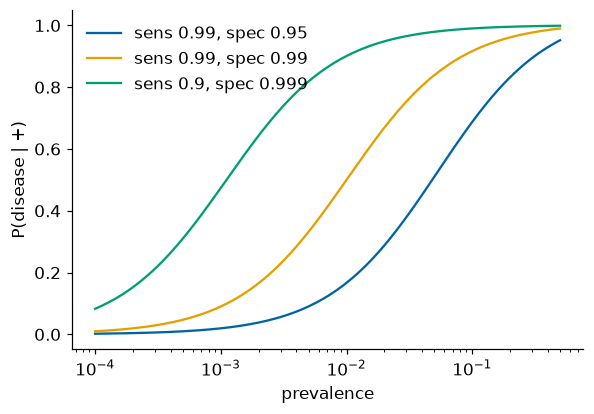

In [2]:
def ppv(sens, spec, prev):
    return sens * prev / (sens * prev + (1 - spec) * (1 - prev))

print(f"sens 99%, spec 95%, prevalence 1%:  PPV = {ppv(0.99, 0.95, 0.01):.3f}")
print(f"same test, prevalence 20% (symptomatic clinic): PPV = {ppv(0.99, 0.95, 0.20):.3f}")
# retest the positives: the posterior after the first test is the prior for the second
# (assumes the two results are conditionally independent given disease status)
p1 = ppv(0.99, 0.95, 0.01)
print(f"second positive test: prior {p1:.3f} -> PPV = {ppv(0.99, 0.95, p1):.3f}")
# natural frequencies
N, prev, sens, spec = 10_000, 0.01, 0.99, 0.95
sick = N * prev
print(f"of {N} people: {sick:.0f} sick -> {sick * sens:.0f} true positives; "
      f"{N - sick:.0f} healthy -> {(N - sick) * (1 - spec):.0f} false positives")

prevs = np.geomspace(1e-4, 0.5, 200)
for se, sp in [(0.99, 0.95), (0.99, 0.99), (0.9, 0.999)]:
    plt.semilogx(prevs, ppv(se, sp, prevs), label=f"sens {se}, spec {sp}")
plt.xlabel("prevalence"); plt.ylabel("P(disease | +)"); plt.legend(); plt.show()

## 2. The Bayes classifier for two Gaussian classes
Class 0: $x\sim\mathcal N(0, 1.2^2)$; class 1: $x\sim\mathcal N(2.5, 1.4^2)$ (a synthetic biomarker). Predict class 1 when $p(y=1\mid x) > t$, where $t=\frac{c_{FP}}{c_{FP}+c_{FN}}$.

In [3]:
def posterior1(x, prior1):
    j0 = (1 - prior1) * norm.pdf(x, 0, 1.2)
    j1 = prior1 * norm.pdf(x, 2.5, 1.4)
    return j1 / (j0 + j1)

xs = np.linspace(-4, 10.5, 800)   # same grid as the slides

def threshold(prior1, t):
    """Biomarker level where the posterior p(y=1|x) crosses t (the crossing inside the plotted range)."""
    return xs[np.argmin(np.abs(posterior1(xs, prior1) - t))]

cost_ratios = [1, 9]   # c_FN / c_FP  (Try it yourself: add 20)
for prior1 in [0.5, 0.1]:
    for cost_ratio in cost_ratios:
        t = 1 / (1 + cost_ratio)
        print(f"prior π1 = {prior1}, c_FN/c_FP = {cost_ratio:2d} (posterior threshold {t:.3f}):  "
              f"predict disease when x > {threshold(prior1, t):.2f}")

prior π1 = 0.5, c_FN/c_FP =  1 (posterior threshold 0.500):  predict disease when x > 1.26
prior π1 = 0.5, c_FN/c_FP =  9 (posterior threshold 0.100):  predict disease when x > -0.35
prior π1 = 0.1, c_FN/c_FP =  1 (posterior threshold 0.500):  predict disease when x > 2.61
prior π1 = 0.1, c_FN/c_FP =  9 (posterior threshold 0.100):  predict disease when x > 1.26


Class 1 has the larger variance, so the posterior rises again far in the left tail (below $x\approx -7$, outside the plotted range): the exact Bayes rule has a second, practically irrelevant boundary there.

Monte-Carlo check that the Bayes rule has the lowest error among threshold rules:

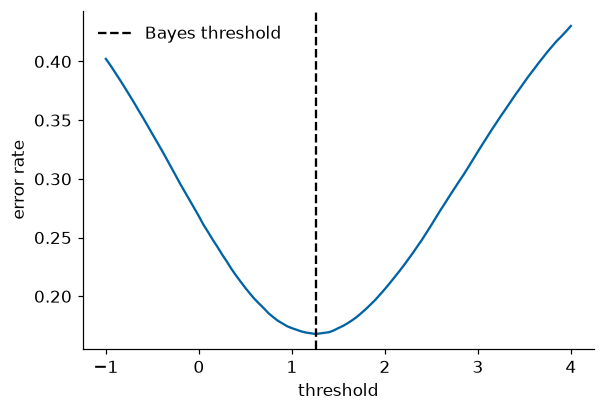

Bayes threshold 1.26; best empirical threshold 1.25; estimated Bayes error 0.168


In [4]:
n = 200_000
y = rng.random(n) < 0.5
x = np.where(y, rng.normal(2.5, 1.4, n), rng.normal(0, 1.2, n))
thresholds = np.linspace(-1, 4, 101)
err = [np.mean((x > t) != y) for t in thresholds]
bayes_thr = threshold(0.5, 0.5)
plt.plot(thresholds, err); plt.axvline(bayes_thr, color="k", ls="--", label="Bayes threshold")
plt.xlabel("threshold"); plt.ylabel("error rate"); plt.legend(); plt.show()
print(f"Bayes threshold {bayes_thr:.2f}; best empirical threshold {thresholds[np.argmin(err)]:.2f}; "
      f"estimated Bayes error {min(err):.3f}")

## 3. Gaussian naive Bayes on breast-cancer biopsies
Naive Bayes assumes the 30 nucleus features are independent given the diagnosis. Many are strongly correlated (radius, perimeter and area measure the same size), so the evidence is double-counted. The classification can still be good, but the probabilities are overconfident.

5-fold CV accuracy: Gaussian naive Bayes 0.939   kNN (k = 5, standardized; Lecture 2) 0.965
naive Bayes ROC AUC (pooled out-of-fold probabilities) = 0.987
corr(mean radius, mean perimeter) = 0.998
fraction of predictions with p < 0.01 or p > 0.99: 0.96


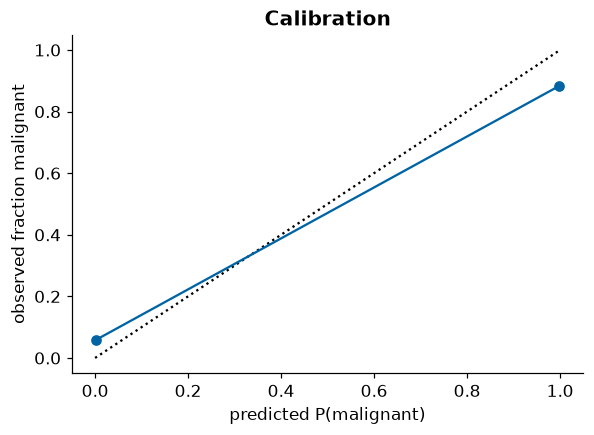

In [5]:
bc = load_breast_cancer()
X, yb = bc.data, 1 - bc.target   # 1 = malignant
cv = StratifiedKFold(5, shuffle=True, random_state=0)
acc_nb = cross_val_score(GaussianNB(), X, yb, cv=cv).mean()
acc_knn = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(5)), X, yb, cv=cv).mean()
print(f"5-fold CV accuracy: Gaussian naive Bayes {acc_nb:.3f}   kNN (k = 5, standardized; Lecture 2) {acc_knn:.3f}")
proba = cross_val_predict(GaussianNB(), X, yb, cv=cv, method="predict_proba")[:, 1]   # same folds
print(f"naive Bayes ROC AUC (pooled out-of-fold probabilities) = {roc_auc_score(yb, proba):.3f}")
print(f"corr(mean radius, mean perimeter) = {np.corrcoef(X[:, 0], X[:, 2])[0, 1]:.3f}")
print(f"fraction of predictions with p < 0.01 or p > 0.99: {np.mean((proba < 0.01) | (proba > 0.99)):.2f}")

# reliability (calibration) diagram
bins = np.linspace(0, 1, 11)
idx = np.digitize(proba, bins) - 1
centers, frac = [], []
for b in range(10):
    m = idx == b
    if m.sum() >= 5:
        centers.append(proba[m].mean()); frac.append(yb[m].mean())
plt.plot([0, 1], [0, 1], "k:"); plt.plot(centers, frac, "o-")
plt.xlabel("predicted P(malignant)"); plt.ylabel("observed fraction malignant"); plt.title("Calibration"); plt.show()

## 4. Transcription-factor binding sites as a generative model

**Data.** CTCF position frequency matrix MA0139.1 from JASPAR (Castro-Mondragon et al., *Nucleic Acids Res.* 2022; data CC BY 4.0), downloaded once through the JASPAR REST API and cached in `applications/data/`. All sequences below are simulated.

**Biology.** Transcription factors (TFs) bind short DNA motifs to regulate genes. CTCF binds a ~19-bp motif and helps organize the 3D structure of the genome. JASPAR (https://jaspar.elixir.no) collects position frequency matrices: counts of each base at each position of aligned binding sites.

**Model.** Position probability matrix $\theta_{w,a} = p(s_w = a\mid\text{motif})$, each position independent (a naive-Bayes assumption), background $q_a$. Score = log-likelihood ratio
$S(\mathbf s) = \sum_w \log\frac{\theta_{w,s_w}}{q_{s_w}}$, and posterior $p(\text{motif}\mid\mathbf s)=\sigma\big(S(\mathbf s)+\log\frac{\pi}{1-\pi}\big)$.

CTCF motif width W = 19


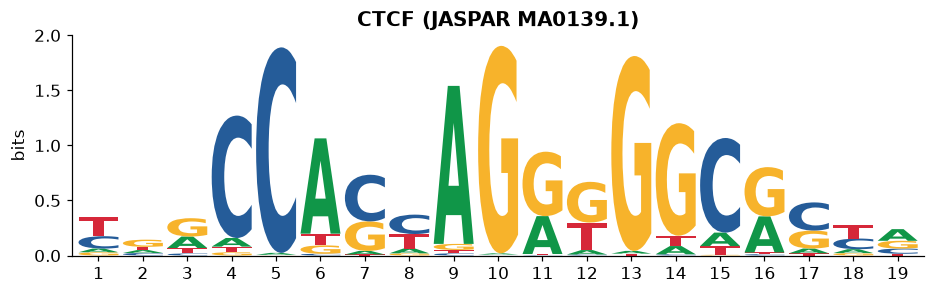

consensus (most likely base per position): TGGCCACCAGGGGGCGCTA


In [6]:
name, counts = cu.load_jaspar("MA0139.1")
theta = cu.pwm_from_counts(counts, pseudocount=0.5)
print(name, "motif width W =", theta.shape[0])
fig, ax = plt.subplots(figsize=(10, 2.6))
cu.plot_logo(ax, theta, title=f"{name} (JASPAR MA0139.1)"); plt.show()
consensus = "".join(cu.BASES[i] for i in theta.argmax(1))
print("consensus (most likely base per position):", consensus)

In [7]:
def llr_scores(seqs, theta, q=np.full(4, 0.25)):
    W = theta.shape[0]
    lr = np.log(theta / q[None])
    idx = np.array([[cu.BASES.index(c) for c in s] for s in seqs])
    return lr[np.arange(W)[None], idx].sum(1)

def posterior(S, prior):
    return 1 / (1 + np.exp(-(S + np.log(prior / (1 - prior)))))

S_cons = llr_scores([consensus], theta)[0]
for prior in [0.5, 1e-3, 1e-6]:
    print(f"consensus site: S = {S_cons:.1f};  posterior with prior {prior:g} = {posterior(S_cons, prior):.3f}")

consensus site: S = 18.1;  posterior with prior 0.5 = 1.000
consensus site: S = 18.1;  posterior with prior 0.001 = 1.000
consensus site: S = 18.1;  posterior with prior 1e-06 = 0.986


### Scanning a sequence
Slide the motif along a sequence and score every window. Real scanners also score the reverse-complement strand.

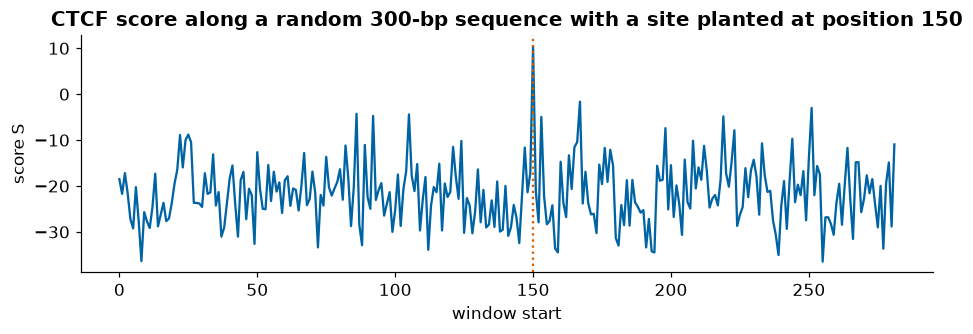

best window at 150 with score 10.5


In [8]:
gc_scan = 0.5                                      # background GC content (Try it yourself: 0.7)
q_scan = np.full(4, 0.25)                          # background model used for scoring; matched: [(1-gc)/2, gc/2, gc/2, (1-gc)/2]
seq = list(cu.random_dna(rng, 1, 300, gc_scan)[0])
site = cu.sample_from_pwm(theta, rng, 1)[0]
seq[150:150 + len(site)] = list(site)
seq = "".join(seq)
W = theta.shape[0]
scores = llr_scores([seq[i:i + W] for i in range(len(seq) - W + 1)], theta, q_scan)
plt.figure(figsize=(10, 2.8)); plt.plot(scores); plt.axvline(150, color="#D55E00", ls=":")
plt.xlabel("window start"); plt.ylabel("score S"); plt.title("CTCF score along a random 300-bp sequence with a site planted at position 150"); plt.show()
print("best window at", scores.argmax(), "with score", round(scores.max(), 1))

### Evaluation: can the best window distinguish sequences with a site from background?
Positives: 200-bp random sequence with one planted site. Negatives: random sequence. Score = best window. We try strong sites (sampled from the PWM) and weaker, more degenerate sites (sampled from a softened PWM $\theta^{0.5}$), and a GC-rich background.

In [9]:
def best_window(seqs, theta, q):
    lr = np.log(theta / q[None])
    out = []
    for s in seqs:
        idx = np.array([cu.BASES.index(c) for c in s])
        win = np.lib.stride_tricks.sliding_window_view(idx, W)
        out.append(lr[np.arange(W)[None], win].sum(1).max())
    return np.array(out)

weak = theta ** 0.5; weak /= weak.sum(1, keepdims=True)
n = 1000
rng_sim = np.random.default_rng(0)   # own generator, as in the lecture, so the AUCs match the slide
for site_name, th_site in [("strong", theta), ("weaker", weak)]:
    for gc in [0.5, 0.7]:
        neg = cu.random_dna(rng_sim, n, 200, gc)
        pos = cu.random_dna(rng_sim, n, 200, gc)
        sites = cu.sample_from_pwm(th_site, rng_sim, n)
        pos = [p[:90] + s + p[90 + W:] for p, s in zip(pos, sites)]
        y = np.r_[np.ones(n), np.zeros(n)]
        q_u = np.full(4, 0.25); q_m = np.array([(1 - gc) / 2, gc / 2, gc / 2, (1 - gc) / 2])
        auc_u = roc_auc_score(y, np.r_[best_window(pos, theta, q_u), best_window(neg, theta, q_u)])
        auc_m = roc_auc_score(y, np.r_[best_window(pos, theta, q_m), best_window(neg, theta, q_m)])
        print(f"{site_name:6s} sites, GC = {gc}:  AUC uniform q = {auc_u:.3f}   matched q = {auc_m:.3f}")

strong sites, GC = 0.5:  AUC uniform q = 0.997   matched q = 0.997


strong sites, GC = 0.7:  AUC uniform q = 0.991   matched q = 0.995


weaker sites, GC = 0.5:  AUC uniform q = 0.827   matched q = 0.827


weaker sites, GC = 0.7:  AUC uniform q = 0.761   matched q = 0.832


## 5. Biological interpretation
- The PWM treats positions as independent, like naive Bayes. Real binding sites have dependencies between neighboring bases, and binding also depends on chromatin accessibility and partner proteins. Convolutional networks (Lecture 11) learn richer patterns from data.
- Background composition matters: CTCF's motif is GC-rich, so GC-rich DNA produces more chance matches. The background model $q$ should match the genomic region.
- A genome has billions of windows. With a prior of about $10^{-6}$, only very high scores give a high posterior. This is why scanning a whole genome with a PWM gives many false positives.

## 6. Try it yourself
1. Change the pseudocount from 0.5 to 5. What happens to rare bases? (Edit `pseudocount=0.5` where `theta` is built; also try 0 and look at the score of a site with a base never seen at some position.)
2. Make the background 70% GC. How should q change? (Pass `gc=0.7` to `cu.random_dna` in the scanning cell and compare scoring with the uniform `q` and with $q = (0.15, 0.35, 0.35, 0.15)$; the AUC table does this systematically.)
3. Set costs c_FN = 20 c_FP: where is the new threshold? (Add 20 to `cost_ratios`.)
4. Replace `GaussianNB` with logistic regression (Lecture 5). Compare accuracy and the calibration plot.
5. *(CS284A)* Extend the scanner to both strands (reverse complement: A↔T, C↔G, reversed). Does the AUC change for the weaker sites?